# 60 Minutes to Pyomo: An Energy Storage Model Predictive Control Example

In [1]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

In [2]:
import pandas as pd
import pyomo.environ as pyo
import numpy as np
import matplotlib.pyplot as plt

## Problem Setup

### Background

In many regions of the world, including the US, electricity generation is scheduled through wholesale electricity markets. Individual generators (resources) transmit information about their operating costs and constraints to the market via a bid. The market operator then solves an optimization problem (e.g., the unit commitment problem) to minimize the total electricity generator cost. The market operator decides which generators to dispatch during each hour to satisfy the forecasted demand while honoring limitations for each generator (e.g., maximum ramp rate, the required time for start-up/shutdown, etc.).

![US_markets](https://www.ferc.gov/sites/default/files/2020-06/map-overview-electric.jpg)

Read more information here:
* https://www.ferc.gov/industries-data/market-assessments/electric-power-markets
* https://www.sciencedirect.com/science/article/pii/S0306261916318487

### Pandas and Energy Prices

The CSV (comma separated value) file `Prices_DAM_ALTA2G_7_B1.csv` contains price data for a single location in California for an entire year. The prices are set every hour and have units $/MWh. We will use the package `pandas` to import and analyze the data.

In [3]:
# Load the data file
ca_data = pd.read_csv("../data/Prices_DAM_ALTA2G_7_B1.csv", names=["price"])

# Print the first 10 rows
ca_data.head()

,price
0,36.757
1,34.924
2,33.389
3,32.035
4,33.694


Next we can calculate summary statistics:

In [4]:
ca_data.describe()

,price
count,8760.000000
mean,32.516994
std,9.723477
min,-2.128700
25%,26.510000
50%,30.797500
75%,37.544750
max,116.340000


<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: What are 2 or 3 interesting observations from these summary statistics?
</div>

Next, let's visualize the data in a histogram:

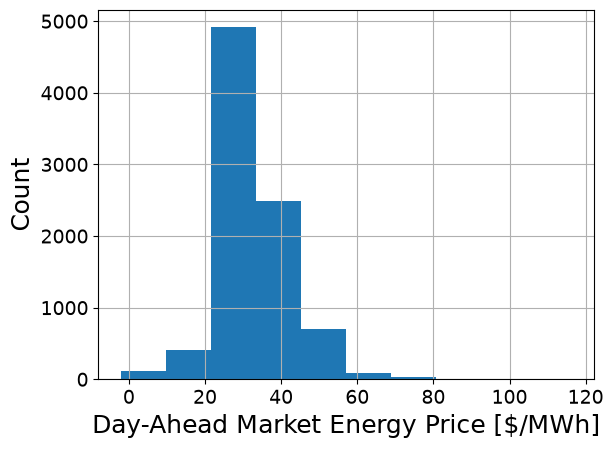

In [5]:
plt.hist(ca_data["price"])
plt.xlabel("Day-Ahead Market Energy Price [$/MWh]", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.grid(True)
plt.show()

Finaly, let's visualize the prices during the first full calendar week. The data are for calendar year 2015. For reference, January 1, 2015 was a Thursday.

```{note}
The canonical version of this figure is rendered once, from
[`figures/plots/dam-price-week.py`](https://github.com/ndcbe/optimization/blob/main/figures/plots/dam-price-week.py),
and is the same picture that appears in the Lecture 1 handout. The live cell below redraws it so you
can change the window; if the two ever disagree, the script is the source of truth.
```

![One calendar week of day-ahead price](../../media/figures/dam-price-week.png)


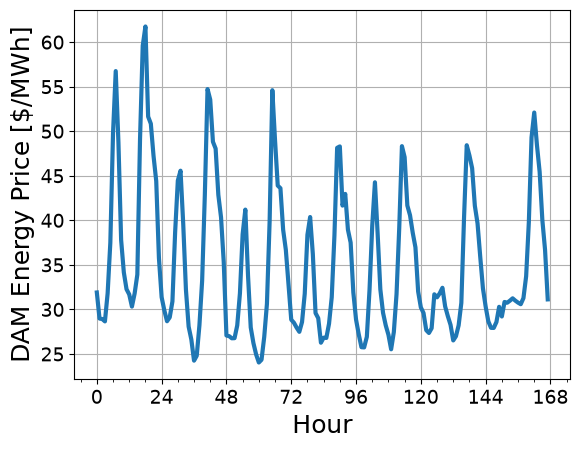

In [6]:
offset = 4  # days
number_of_days = 7
first_week = ca_data["price"].to_numpy()[
    (0 + offset) * 24 : (0 + offset + number_of_days) * 24
]

# Customize the major and minor ticks on the plots
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots()

# Plot data
ax.plot(range(0, number_of_days * 24), first_week)

# Set major ticks every 24 hours (1 day)
ax.xaxis.set_major_locator(MultipleLocator(24))

# Set minor ticks every 6 hours
ax.xaxis.set_minor_locator(MultipleLocator(6))

# Set labels, add grid
plt.xlabel("Hour", fontsize=18)
plt.ylabel("DAM Energy Price [$/MWh]", fontsize=18)
plt.grid(True)
plt.show()

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: What are 1 or 2 interesting observations from these plots?
</div>

### Optimization Mathematical Model

*Energy (price) arbitrage* is the idea of using energy storage (e.g., a battery) to take advantage of the significant daily energy price swings. This gives rise to many analysis questions including:

*If a battery energy storage system perfectly timed it's energy purchases and sales (i.e., it could perfectly forecast the market price), how much money could it make from energy arbitrage?*

We can answer this question using mathematical/computational optimization!

Let's start by drawing a picture.

![battery-optimization](../../media/battery.png)

#### Sets
Let's say we want to define our optimization problem over a 24 hour window. The day-ahead market sets the energy prices in 1-hour intervals. We'll define the set

$$\mathcal{T} = \{0, 1, ..., N\}$$

for time where $N = 24$ for a 24-hour planning horizon. For convienence, we'll also define $\mathcal{T}' := \mathcal{T} / \{0\}$, which is the original set $\mathcal{T}$ substract subset $\{0\}$.


#### Variables

Next, let's identify the variables in the optimization problem:
* $E_t$, energy stored in battery at time $t$, units: MWh
* $d_t$, battery discharge power (sold to market) during time interval [t-1, t), units: MW
* $c_t$, battery charge power (purchased from the market) during time interval [t-1, t), units: MW

Notice how all of these variables are indexed by the timestep $t$. We'll write in the model $t \in \mathcal{T}'$

#### Parameters

Parameters are data that are constant during the optimization problem. Here we have:
* $\pi_t$: Energy price during time interval [t-1, t), units: \$/MW
* $\eta$: Round trip efficiency, units: dimensionless
* $c_{max}$ Maximum charge power, units: MW
* $d_{max}$ Maximum discharge power, units: MW
* $E_{max}$ Maximum storage energy, units: MWh
* $E_{0}$ Energy in storage at time $t=0$, units: MWh
* $\Delta t = 1$ hour, Timestep for grid decisions and prices (fixed)

#### Objective and Constraints

Finally, we'll identify the objective, which is the function to improve, and the mathematical constraints. Below is the full mathematical model for the problem:

$$
\begin{align*}
    \max_{\mathbf{E},\mathbf{d},\mathbf{c}} \quad & \psi := \sum_{t \in \mathcal{T}'} \pi_{t} \Delta t (d_{t} - c_{t}) \\
\mathrm{s.t.} \quad & E_{t} = E_{t-1} + \Delta t \left( c_{t} \sqrt{\eta} - \frac{d_{t}}{\sqrt{\eta}} \right), ~~ \forall ~ t \in \mathcal{T}' \\
    & E_{0} = E_{N} \\
    & 0 \leq c_{t} \leq c_{max}, ~~\forall ~ t \in \mathcal{T}' \\
    & 0 \leq d_{t} \leq d_{max}, ~~\forall ~ t \in \mathcal{T}' \\
    & 0 \leq E_{t} \leq E_{max},  ~~\forall ~ t \in \mathcal{T}'
\end{align*}
$$

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Write on paper a 1-sentence description for each equation.
</div>

### Degree of Freedom Analysis

Before we program our model in Pyomo, it is *very important* to first perform a degree of freedom analysis. Here are the steps:
* Count the number of variables
* Count the number of equality constraints
* Degrees of freedom = number of variables subtract number of equality constraints

The degrees of freedom are the number of decisions variables that be freely manipulated by the optimizer. If there are no degrees of freedom, we ofter say the problem is square or it is a simulation problem.

For now, we will ignore inequality constraints and bounds. Later in the semester we will revisit degree of freedom analysis using some optimization theory concepts (e.g., active sets).

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Perform degree of freedom analysis.
</div>

## Pyomo Modeling Components

<div style="background-color: rgba(255,0,0,0.05) ; padding: 10px; border: 1px solid darkred;"> 
<b>Important</b>: Do NOT implement an optimization model in Pyomo (or any other software) until you have written it on paper and performed degree of freedom analysis, as done above. Be sure to resolve any doubts, questions, or concerns while your model is still on paper. When applying optimization to a problem, a majority of the mistakes happen at the problem formulation step. So do not rush it!
</div>

### Create `ConcreteModel`

We will start by creating a concrete Pyomo model. Recall, Pyomo is an object-oriented algebriac modeling language. The line below creates an instance of the ConcreteModel class.

In [7]:
m = pyo.ConcreteModel()

For those unfamilar with object-oriented programming, `m` is a container to define an optimization model. It includes a bunch of functionality to interface with different optimization solvers, perform diagnostics, and inspect the solution.

Pyomo also supports abstract models, but we will stick with concrete models this semester. See the Pyomo textbook for more details if you are curious.

### Sets

We start by declaring a set for time. From above, recall we want to index all of the variables and constraints over the set

$$
\mathcal{T}' = \mathcal{T} / \{0\} = \{1, ..., N\}
$$

In [8]:
# Save the number of timesteps
m.N = 24

# Define the horizon set
m.HORIZON = pyo.Set(initialize=range(1, m.N + 1))

Some Pyomo modelers prefer to use all capital names for sets; this is a personal preference.

### Variables

Next, we can declare our three variables: $E_t$, $c_t$, $d_t$

In [9]:
# Charging rate [MW]
m.c = pyo.Var(m.HORIZON, initialize=0.0, bounds=(0, 1), domain=pyo.NonNegativeReals)

# Discharging rate [MW]
m.d = pyo.Var(m.HORIZON, initialize=0.0, bounds=(0, 1), domain=pyo.NonNegativeReals)

# Energy (state-of-charge) [MWh]
m.E = pyo.Var(m.HORIZON, initialize=0.0, bounds=(0, 4), domain=pyo.NonNegativeReals)

See the table below (Hart et al., 2017) for an explanation of the arguments for `Var`:
    
![pyomo-var-arguments](../../media/pyomo-table-4.1.png)

Pyomo also supports units. Even though we are not explicitly using the feature, the units for all variables are clearly marked in the comments.

The following table (Hart et al., 2017) shows the options for the `within`/`domain` variable keyword:

![pyomo-var-domain](../../media/pyomo-table-4.2.png)


In the example above, `domain=pyo.NonNegativeReals` is not needs, as we are specifying stricker bounds. It is included above to show the syntax.

### Parameters (Constants / Data)

The next step is to define the parameter data: $\pi_t$ (energy prices), $\eta$ (round trip efficiency) and $E_0$ (intial energy storage level).

In [10]:
# Square root of round trip efficiency
m.sqrteta = pyo.Param(initialize=pyo.sqrt(0.88))

# Energy in battery at t=0
m.E0 = pyo.Param(initialize=2.0, mutable=True)

In [11]:
m.pprint()

1 Set Declarations
    HORIZON : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   24 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}

2 Param Declarations
    E0 : Size=1, Index=None, Domain=Any, Default=None, Mutable=True
        Key  : Value
        None :   2.0
    sqrteta : Size=1, Index=None, Domain=Any, Default=None, Mutable=False
        Key  : Value
        None : 0.938083151964686

3 Var Declarations
    E : Size=24, Index=HORIZON
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :     0 :   0.0 :     4 : False : False : NonNegativeReals
          2 :     0 :   0.0 :     4 : False : False : NonNegativeReals
          3 :     0 :   0.0 :     4 : False : False : NonNegativeReals
          4 :     0 :   0.0 :     4 : False : False : NonNegativeReals
          5 :     0 :   0.0 :     4 : False : False : NonNegativeReals
          6 :     0 :   0.0 

We see the `initialize` keyword is used to set the parameter value. When `mutable=True`, Pyomo builds the model such that we can easily update the parameter and resolved. Later in the notebook, we will see how this is helpful.

Below is a table (Hart et al., 2017) of options for `Param`:

    
![pyomo-param-arguments](../../media/pyomo-table-4.6.png)

Let's dig in more to the `initialize` syntax. First, let's convert the price data from pandas into a numpy array:

In [12]:
my_np_array = ca_data["price"].to_numpy()

# get the length
print("len(my_np_array) =", len(my_np_array))

len(my_np_array) = 8760


Recall, our dataset constains an entire year (which has 8760 hours). To access the first 24 hours, we use the following slice:

In [13]:
my_np_array[0:24]

array([36.757, 34.924, 33.389, 32.035, 33.694, 36.88 , 38.662, 38.975,
       35.08 , 29.979, 27.546, 25.944, 24.587, 23.788, 25.236, 30.145,
       44.622, 50.957, 59.345, 52.564, 52.819, 48.816, 46.685, 38.575])

In [14]:
len(my_np_array[0:24])

24

Initializing parameters in Pyomo can be precarious. The most fool proof strategy is to prepare a dictionary where the keys match the elements of the sets that index the parameter of interest. In our example, `m.HORIZON` contains 1, ..., 24, so we need a dictionary with the keys 1, ..., 24.

In [15]:
ca_data["price"][0:24].to_dict()

{0: 36.757,
 1: 34.924,
 2: 33.389,
 3: 32.035,
 4: 33.694,
 5: 36.88,
 6: 38.662,
 7: 38.975,
 8: 35.08,
 9: 29.979,
 10: 27.546,
 11: 25.944,
 12: 24.587,
 13: 23.788,
 14: 25.236,
 15: 30.145,
 16: 44.622,
 17: 50.957,
 18: 59.345,
 19: 52.564,
 20: 52.819,
 21: 48.816,
 22: 46.685,
 23: 38.575}

That was easy. But what if we wanted to build the optimization model using the second day of data? Let's give it a try:

In [16]:
ca_data["price"][24:48].to_dict()

{24: 37.239,
 25: 34.766,
 26: 34.645,
 27: 33.21,
 28: 35.524,
 29: 44.143,
 30: 39.231,
 31: 41.251,
 32: 36.406,
 33: 31.194,
 34: 29.695,
 35: 27.034,
 36: 26.009,
 37: 24.829,
 38: 26.168,
 39: 29.921,
 40: 44.137,
 41: 51.751,
 42: 51.652,
 43: 46.675,
 44: 45.274,
 45: 44.053,
 46: 46.779,
 47: 37.307}

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Uncomment the line below and look at the error message and read below. Then comment the line out again and rerun the notebook up to this cell.
</div>

In [17]:
# m.price = pyo.Param(m.HORIZON, initialize = ca_data["price"][24:48].to_dict(), domain=pyo.Reals)

You should get the following error:

```
ERROR: Constructing component 'price' from data=None failed: KeyError: "Index
    '25' is not valid for indexed component 'price'"
```

Why did this happen? Our dictionary started with key 25 but we tried to create a `Param` indexed over 1 through 24.

Let's say we want to build the optimization model starting for an arbitrary day. We need to extract the correct data from the pandas DataFrame and convert it to a dictionary with the correct keys. The function below does this using a simple, easy to follow approach. There is more compact "Pythonic" syntax to do this, but we will skip it for this getting started tutorial.

In [18]:
def prepare_price_data(day):
    """Prepare dictionary of price data

    Arugments:
        day: int, day to start. day = 0 is the first day

    Returns:
        data_dict: dictionary of price data with keys 1 to 24

    Notes:
        This function assumes the pandas DataFrame ca_data is in scope.

    """

    # Create empty dictionary
    data_dict = {}

    # Extract data as numpy array
    data_np_array = ca_data["price"][(day) * 24 : 24 * (day + 1)].to_numpy()

    # Loop over elements of numpy array
    for i in range(0, 24):

        # Add element to data_dict
        data_dict[i + 1] = data_np_array[i]

    return data_dict


# Create input data for day 1 (i.e., January 2, 2015)
my_data_dict = prepare_price_data(1)
print(my_data_dict)

{1: np.float64(37.239), 2: np.float64(34.766), 3: np.float64(34.645), 4: np.float64(33.21), 5: np.float64(35.524), 6: np.float64(44.143), 7: np.float64(39.231), 8: np.float64(41.251), 9: np.float64(36.406), 10: np.float64(31.194), 11: np.float64(29.695), 12: np.float64(27.034), 13: np.float64(26.009), 14: np.float64(24.829), 15: np.float64(26.168), 16: np.float64(29.921), 17: np.float64(44.137), 18: np.float64(51.751), 19: np.float64(51.652), 20: np.float64(46.675), 21: np.float64(45.274), 22: np.float64(44.053), 23: np.float64(46.779), 24: np.float64(37.307)}


<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Confirm <tt>my_data_dict</tt> contains the correct prices for the January 2, 2015.
</div>

In [19]:
### BEGIN SOLUTION
ca_data["price"][24:48].to_numpy()
### END SOLUTION

array([37.239, 34.766, 34.645, 33.21 , 35.524, 44.143, 39.231, 41.251,
       36.406, 31.194, 29.695, 27.034, 26.009, 24.829, 26.168, 29.921,
       44.137, 51.751, 51.652, 46.675, 45.274, 44.053, 46.779, 37.307])

Now we are ready to define the price data parameter:

In [20]:
m.price = pyo.Param(m.HORIZON, initialize=my_data_dict, domain=pyo.Reals, mutable=True)

<div style="background-color: rgba(0,255,0,0.05) ; padding: 10px; border: 1px solid darkgreen;"> 
<b>Tip</b>: When initializing variables and parameters with a pandas DataFrame, always convert to dictionary and check the keys. Often incorrectly loaded data is the root cause of unexpected errors or strange results. Checking the keys while building the model helps prevent these mistakes. 
</div>

### Objectives

Next, we will declare the objective function in Pyomo. Below are two equally valid syntaxes. The first, using the `@m.Objective` decorator, is the house style for this course. (The LP notebook has an aside comparing the decorator with the older `rule=` keyword; the two are equivalent.)


In [21]:
# Approach 1 (house style): the @m.Objective decorator
@m.Objective(sense=pyo.maximize)
def OBJ(b):
    return sum((-b.c[t] + b.d[t]) * b.price[t] for t in b.HORIZON)


# Approach 2: build the expression inline with *expr=*
# m.OBJ = pyo.Objective(
#     expr=sum((-m.c[t] + m.d[t]) * m.price[t] for t in m.HORIZON),
#     sense=pyo.maximize,
# )

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Uncomment Approach 2 above and rerun the notebook. Pyomo will warn you it is replacing the component <tt>OBJ</tt>, because Approach 1 already declared it. The answer should not change. Then comment Approach 2 out again.
</div>


The following table (Hart et al., 2017) summarizes the keyword arguments for `Objective`:

![pyomo-objective-arguments](../../media/pyomo-table-4.3.png)

### Constraints

Now let's add the last model component: the constraints.

In [22]:
# Define Energy Balance constraints. [MWh] = [MW]*[1 hr]
# Note: this model assumes 1-hour timestep in price data and control actions.
@m.Constraint(m.HORIZON)
def EnergyBalance_Con(b, t):
    # First timestep
    if t == 1:
        return b.E[t] == b.E0 + b.c[t] * b.sqrteta - b.d[t] / b.sqrteta

    # Subsequent timesteps
    else:
        return b.E[t] == b.E[t - 1] + b.c[t] * b.sqrteta - b.d[t] / b.sqrteta


# Periodic boundary: energy stored at the final time equals the initial [MWh]
m.PeriodicBoundaryCondition = pyo.Constraint(expr=m.E0 == m.E[m.N])

Notice the above model includes detailed comments with the units for the left-hand side and right-hand side of each equation. This is strongly recommend; it is easy for units mistakes to go undetected in a complicated Pyomo model. Alternately, you can also use the units feature in Pyomo.

We see in this example a big advantage of defining a constraint with a **rule function** instead of a single `expr=`. Inside the function `EnergyBalance_Con` we incorporate a logical statement for how to handle the first timestep (which uses parameter `E0`).

Below is a table of keyword arguments for `Constraint`:

![pyomo-constraint-arguments](../../media/pyomo-table-4.4.png)

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Compare the two model equations above to the optimization formulation below. Notice the one-to-one corespondance between the equality constraints in the mathematical formulation (below) and calls to <tt>pyo.Constraint</tt>. Also notice the sets used to create the Pyomo model are listed next to each constraint in the mathematical model. Once you learn the Pyomo syntax, translated a mathematical model into code is easy! 
</div>

### Printing the Model

Here is the optimization model, reproduced from above for convenience:

$$
\begin{align*}
    \max_{\mathbf{E},\mathbf{d},\mathbf{c}} \quad & \psi := \sum_{t \in \mathcal{T}'} \pi_{t} \Delta t (d_{t} - c_{t}) \\
\mathrm{s.t.} \quad & E_{t} = E_{t-1} + \Delta t \left( c_{t} \sqrt{\eta} - \frac{d_{t}}{\sqrt{\eta}} \right), ~~ \forall ~ t \in \mathcal{T}' \\
    & E_{0} = E_{N} \\
    & 0 \leq c_{t} \leq c_{max}, ~~\forall ~ t \in \mathcal{T}' \\
    & 0 \leq d_{t} \leq d_{max}, ~~\forall ~ t \in \mathcal{T}' \\
    & 0 \leq E_{t} \leq E_{max},  ~~\forall ~ t \in \mathcal{T}'
\end{align*}
$$

Now let's see if our Pyomo model matches the optimization formulation. We will use the `pprint()` command (pretty print) to inspect the full model.

In [23]:
m.pprint()

1 Set Declarations
    HORIZON : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   24 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}

3 Param Declarations
    E0 : Size=1, Index=None, Domain=Any, Default=None, Mutable=True
        Key  : Value
        None :   2.0
    price : Size=24, Index=HORIZON, Domain=Reals, Default=None, Mutable=True
        Key : Value
          1 : 37.239
          2 : 34.766
          3 : 34.645
          4 :  33.21
          5 : 35.524
          6 : 44.143
          7 : 39.231
          8 : 41.251
          9 : 36.406
         10 : 31.194
         11 : 29.695
         12 : 27.034
         13 : 26.009
         14 : 24.829
         15 : 26.168
         16 : 29.921
         17 : 44.137
         18 : 51.751
         19 : 51.652
         20 : 46.675
         21 : 45.274
         22 : 44.053
         23 : 46.779
         24 : 37.307
    sqrteta : Size=1, 

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Does our Pyomo model match the optimization mathematical model (equations above)? How did we incorporate the inequality constraints into the Pyomo model?
</div>

### Another Approach: Build the Model in a Function

To emphasize the tutorial nature of this example, we build the model on piece at a time above. An often preferred approach is to define a Python function that builds the model, such as the one below.

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: The function below uses elements of <tt>price</tt> directly. Update the function to add the price data as a parameter in the Pyomo model. Make this parameter mutable as shown above.
</div>

In [24]:
# define a function to build model
def build_model(price, e0=0):
    """
    Create optimization model for MPC

    Arguments (inputs):
        price: NumPy array with energy price timeseries
        e0: initial value for energy storage level

    Returns (outputs):
        my_model: Pyomo optimization model
    """

    # Create a concrete Pyomo model. We'll learn more about this in a few weeks
    my_model = pyo.ConcreteModel()

    ## Define Sets

    # Number of timesteps in planning horizon
    my_model.HORIZON = pyo.Set(initialize=range(len(price)))

    ## Define Parameters

    # Square root of round trip efficiency
    my_model.sqrteta = pyo.Param(initialize=pyo.sqrt(0.88))

    # Energy in battery at t=0
    my_model.E0 = pyo.Param(initialize=e0, mutable=True)

    ## Define variables

    # Charging rate [MW]
    my_model.c = pyo.Var(my_model.HORIZON, initialize=0.0, bounds=(0, 1))

    # Discharging rate [MW]
    my_model.d = pyo.Var(my_model.HORIZON, initialize=0.0, bounds=(0, 1))

    # Energy (state-of-charge) [MWh]
    my_model.E = pyo.Var(my_model.HORIZON, initialize=0.0, bounds=(0, 4))

    ## Define constraints

    # Define Energy Balance constraints. [MWh] = [MW]*[1 hr]
    # Note: this model assumes 1-hour timestep in price data and control actions.
    @my_model.Constraint(my_model.HORIZON)
    def EnergyBalance_Con(b, t):
        # First timestep
        if t == 0:
            return b.E[t] == b.E0 + b.c[t] * b.sqrteta - b.d[t] / b.sqrteta

        # Subsequent timesteps
        else:
            return b.E[t] == b.E[t - 1] + b.c[t] * b.sqrteta - b.d[t] / b.sqrteta

    # Periodic boundary: energy stored at the final time equals the initial [MWh]
    my_model.PeriodicBoundaryCondition = pyo.Constraint(
        expr=my_model.E0 == my_model.E[len(price) - 1]
    )

    ## Define the objective function (profit)
    # Receding horizon
    def objfun(model):
        return sum((-model.c[t] + model.d[t]) * price[t] for t in model.HORIZON)

    my_model.OBJ = pyo.Objective(rule=objfun, sense=pyo.maximize)

    return my_model

## Calling Optimization Solver

Now that our Pyomo model is complete, we can numerically solve the model!

### `SolverFactory` and Solver Options

Algebraic Modeling Languages, including Pyomo, allow us to define optimization problems is a general, solver agnostic way. This means we can quickly swap between solvers.

We will start by using Ipopt. First, we will create an instance of the `SolverFactory`:

In [25]:
# Specify the solver
solver = pyo.SolverFactory("ipopt")

Next we can specify options for `ipopt` such as setting the maximum number of iterations to 50:

In [26]:
solver.options["max_iter"] = 50

Above `solver` is a `SolverFactory` objection which includes the dictionary `options` used to set solver specific options.

Finally, we are ready to solve our model!

In [27]:
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

Ipopt 3.14.19: max_iter=50


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       96
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       72
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       72
                     variables with only upper bounds:        0
Total number of equality constraints.................:       25


   1  1.6802497e-01 1.96e+00 9.85e+00  -1.0 1.99e+00    -  5.21e-03 1.44e-02f  1
   2  2.1332988e+00 1.75e+00 9.89e+00  -1.0 1.96e+00    -  1.53e-02 1.09e-01f  1


   3  2.8652446e+00 1.35e+00 8.39e+00  -1.0 2.08e+00    -  1.09e-01 2.30e-01f  1


   4 -4.0482581e+00 1.01e+00 7.83e+00  -1.0 1.86e+00    -  6.95e-02 2.48e-01f  1
   5 -1.9676532e+01 8.93e-01 8.09e+00  -1.0 7.32e+00    -  6.32e-02 1.17e-01f  1


   6 -3.4249188e+01 7.76e-01 7.89e+00  -1.0 6.21e+00    -  7.33e-02 1.32e-01f  1
   7 -4.6657256e+01 6.62e-01 6.69e+00  -1.0 4.81e+00    -  1.52e-01 1.47e-01f  1
   8 -5.7915679e+01 5.23e-01 5.29e+00  -1.0 3.16e+00    -  2.06e-01 2.09e-01f  1
   9 -6.3119259e+01 3.85e-01 3.92e+00  -1.0 1.34e+00    -  2.30e-01 2.65e-01f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10 -6.3706910e+01 3.12e-02 6.94e+00  -1.0 1.08e+00    -  2.85e-01 9.19e-01f  1
  11 -6.5994667e+01 7.15e-03 3.17e+00  -1.0 6.93e-01    -  4.40e-01 7.71e-01f  1
  12 -6.6628205e+01 3.78e-03 7.49e-01  -1.0 9.35e-01    -  1.00e+00 4.72e-01f  1
  13 -6.9888933e+01 5.35e-04 1.10e-01  -1.7 2.22e-01    -  8.88e-01 8.58e-01f  1
  14 -7.1043057e+01 8.75e-05 1.55e-02  -2.5 2.18e-01    -  7.83e-01 8.36e-01f  1
  15 -7.1364922e+01 1.18e-05 3.85e-02  -3.8 2.82e-01    -  6.56e-01 8.65e-01f  1
  16 -7.1428935e+01 4.44e-16 7.22e-03  -3.8 5.71e-02    -  8.66e-01 1.00e+00f  1
  17 -7.1430287e+01 4.44e-16

The keyword argument `tee=True` tells the solve to dispaly its output to the screen.

### Interpreting Ipopt Output - Verifying Degree of Freedom Analysis

Your Ipopt output should include the following:

```
Number of nonzeros in equality constraint Jacobian...:       96
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       72
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       72
                     variables with only upper bounds:        0
Total number of equality constraints.................:       25
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0
```

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Compare this output to your degree of freedom analysis.
</div>

## Inspecting the Solution

We can inspect the entire model solution using `pprint()`.

In [28]:
m.pprint()

1 Set Declarations
    HORIZON : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   24 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}

3 Param Declarations
    E0 : Size=1, Index=None, Domain=Any, Default=None, Mutable=True
        Key  : Value
        None :   2.0
    price : Size=24, Index=HORIZON, Domain=Reals, Default=None, Mutable=True
        Key : Value
          1 : 37.239
          2 : 34.766
          3 : 34.645
          4 :  33.21
          5 : 35.524
          6 : 44.143
          7 : 39.231
          8 : 41.251
          9 : 36.406
         10 : 31.194
         11 : 29.695
         12 : 27.034
         13 : 26.009
         14 : 24.829
         15 : 26.168
         16 : 29.921
         17 : 44.137
         18 : 51.751
         19 : 51.652
         20 : 46.675
         21 : 45.274
         22 : 44.053
         23 : 46.779
         24 : 37.307
    sqrteta : Size=1, 

The solution is stored in the `value` column. This is helpful for debugging small models but tendious overwise.

### Extracting Solution from Pyomo

A key advantage of Pyomo is that it is an Algebriac Modeling Language in Python. So let's use Python to analyze the solution! The code below extracts the values of the variables into three lists.

In [29]:
# Declare empty lists
c_control = []
d_control = []
E_control = []
t = []

# Loop over elements of HORIZON set.
for i in m.HORIZON:

    t.append(pyo.value(i))

    # Use value( ) function to extract the solution for each varliable and append to the results lists
    c_control.append(pyo.value(m.c[i]))

    # Adding negative sign to discharge for plotting
    d_control.append(-pyo.value(m.d[i]))
    E_control.append(pyo.value(m.E[i]))

In [30]:
print(c_control)

[-9.076328447621595e-09, 4.6129851843523947e-10, 1.122514944905246e-08, 1.0000000080920235, -7.490198166696666e-09, -9.73946041078044e-09, -9.467503770713836e-09, -9.62738555755113e-09, -9.290166798169277e-09, -7.355527199353288e-09, 0.2640142612132261, 1.0000000090593126, 1.0000000093207904, 1.0000000094853687, 1.00000000928996, 1.2446343188330316e-08, -9.455132910884623e-09, -9.763089225431266e-09, -9.76086851816158e-09, -9.544553817218357e-09, -9.38896262841655e-09, -9.129905968825594e-09, -9.553001939840134e-09, 1.0000000093514616]


In [31]:
print(d_control)

[8.742124515838657e-09, 9.438788399508391e-09, 9.453598751691869e-09, 9.583826216205655e-09, 9.323934919922207e-09, -1.0000000094896713, -0.7561663177961923, -1.0000000087577736, 7.744422310674892e-09, 9.224806661720392e-09, 9.38115043785625e-09, 9.626755519759847e-09, 9.676216348762537e-09, 9.719046740968002e-09, 9.669365106869226e-09, 9.365331800203448e-09, 7.266080721118435e-09, -1.000000009495081, -1.0000000094848978, -1.3022687125349388e-08, 8.340935817994683e-09, 9.082574214544385e-09, -0.7561662932747802, 9.735617830533423e-09]


In [32]:
print(E_control)

[2.000000000804785, 2.0000000112993037, 2.0000000319069975, 2.938083201679067, 2.9380832045919867, 1.8720796035614873, 1.0660035914895196, -8.655638723553363e-09, -9.115005753876427e-09, -6.181424950803798e-09, 0.24766733414144607, 1.1857505048666765, 2.12383367588992, 3.061916847113209, 4.000000018100228, 4.00000003975941, 4.000000038635377, 2.933996437576945, 1.8679928365314515, 1.8679928136956352, 1.8679928137794752, 1.867992814896921, 1.061916828884662, 2.0]


### Visualizing the Solution

```{note}
The canonical version of the solution figures is rendered once, from
[`figures/plots/battery-arbitrage.py`](https://github.com/ndcbe/optimization/blob/main/figures/plots/battery-arbitrage.py),
which re-solves this LP with `scipy.optimize.linprog` and carries the price, the charge/discharge
decision and the state of charge as one three-panel picture. It is the figure in the Lecture 1
handout. The live cells below plot the Pyomo solution; because this LP has alternative optima, the
two schedules may differ while the profit does not.
```

![Optimal battery arbitrage: price, power and state of charge](../../media/figures/battery-arbitrage.png)


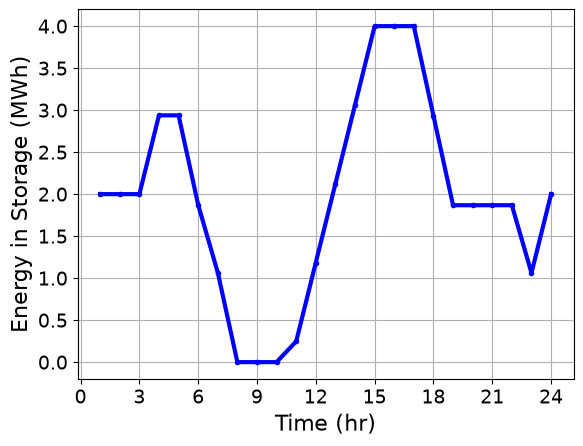

In [33]:
# Plot the state of charge (E)
plt.figure()

# add E0
t_ = [0] + t

E_control_ = [pyo.value(m.E0)] + E_control

plt.plot(t, E_control, "b.-")
plt.xlabel("Time (hr)")
plt.ylabel("Energy in Storage (MWh)")
plt.xticks(range(0, 25, 3))
plt.grid(True)
plt.show()

# This should NOT be a stair plot as energy is the integral of power. The graph below is reasonable.

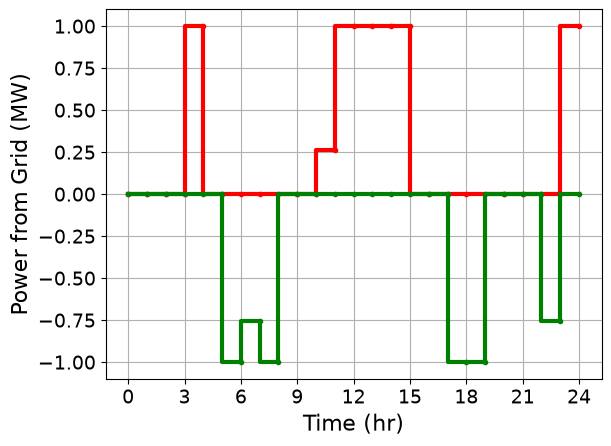

In [34]:
# Plot the charging and discharging rates
plt.figure()

# double up first data point to make the step plot
c_control_ = [c_control[0]] + c_control
d_control_ = [d_control[0]] + d_control

plt.step(t_, c_control_, "r.-", where="pre")
plt.step(t_, d_control_, "g.-", where="pre")
plt.xlabel("Time (hr)")
plt.ylabel("Power from Grid (MW)")
plt.xticks(range(0, 25, 3))
plt.grid(True)
plt.show()

### Accessing Dual Variables

In [35]:
### Declare all suffixes
# https://pyomo.readthedocs.io/en/stable/pyomo_modeling_components/Suffixes.html#exporting-suffix-data

# Ipopt bound multipliers
m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)

# Ipopt constraint multipliers
m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT_EXPORT)

# Resolve the model
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

Ipopt 3.14.19: max_iter=50


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       96
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       72
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       72
                     variables with only upper bounds:        0
Total number of equality constraints.................:       25


   8 -7.1437868e+01 4.44e-16 7.99e-15  -5.7 4.53e-03    -  1.00e+00 1.00e+00f  1


   9 -7.1437961e+01 8.88e-16 7.48e-15  -8.6 2.04e-05    -  1.00e+00 1.00e+00f  1

Number of Iterations....: 9

                                   (scaled)                 (unscaled)
Objective...............:  -7.1437960657845522e+01   -7.1437960657845522e+01
Dual infeasibility......:   7.4779217428591052e-15    7.4779217428591052e-15
Constraint violation....:   8.8817841970012523e-16    8.8817841970012523e-16
Variable bound violation:   3.9759201264644162e-08    3.9759201264644162e-08
Complementarity.........:   3.3122665150541337e-09    3.3122665150541337e-09
Overall NLP error.......:   3.3122665150541337e-09    3.3122665150541337e-09


Number of objective function evaluations             = 10
Number of objective gradient evaluations             = 10
Number of equality constraint evaluations            = 10
Number of inequality constraint evaluations          = 0
Number of equality constraint Jacobian evaluations   = 10
Number of inequality constraint Jacobian evaluations = 0
Number o

In [36]:
# Inspect dual variables for lower bound
m.ipopt_zL_out.display()

ipopt_zL_out : Direction=IMPORT, Datatype=FLOAT
    Key   : Value
    E[10] :      -0.794241619316072
    E[11] :  -9.959159559145174e-09
    E[12] :  -2.102627169661387e-09
    E[13] :  -1.175782908727664e-09
    E[14] :  -8.162117659813141e-10
    E[15] :    -6.2506885965562e-10
    E[16] :  -6.264563243789251e-10
    E[17] :  -6.263268931807182e-10
    E[18] :  -8.539379352204578e-10
    E[19] :  -1.341422206806913e-09
     E[1] : -1.2527829785585504e-09
    E[20] :  -1.341350289904925e-09
    E[21] : -1.3409814411365547e-09
    E[22] : -1.3409540074980453e-09
    E[23] : -2.3608437770291847e-09
    E[24] : -1.2529517735752844e-09
     E[2] : -1.2561427947619423e-09
     E[3] : -1.2655652532929373e-09
     E[4] :  -8.577658488886522e-10
     E[5] :  -8.581114250870307e-10
     E[6] : -1.3533628470961722e-09
     E[7] : -2.3510746270035887e-09
     E[8] :     -1.2933647690071222
     E[9] :     -3.0593573861032906
    c[10] :     -0.7539353271121387
    c[11] :  -9.178573911933398e-0

In [37]:
# Inspect dual variables for upper bound
m.ipopt_zU_out.display()

ipopt_zU_out : Direction=IMPORT, Datatype=FLOAT
    Key   : Value
    E[10] :  6.262126510435488e-10
    E[11] :  6.693766261750669e-10
    E[12] :    8.9355974571478e-10
    E[13] : 1.3437267429111052e-09
    E[14] :  2.713588361024654e-09
    E[15] :    0.14094426689949266
    E[16] :      10.74974729064419
    E[17] :      1.336923856231947
    E[18] :  2.351928363328083e-09
    E[19] : 1.1754291485433243e-09
     E[1] :  1.253120766471938e-09
    E[20] :  1.175503900129797e-09
    E[21] : 1.1758414697720055e-09
    E[22] : 1.1758669537676752e-09
    E[23] :   8.52768230140698e-10
    E[24] : 1.2529517547809998e-09
     E[2] : 1.2502665613514982e-09
     E[3] :   1.24632281279438e-09
     E[4] : 2.3442194466299494e-09
     E[5] : 2.3435146974157423e-09
     E[6] : 1.1716539589773153e-09
     E[7] :  8.540487163434175e-10
     E[8] :  6.263114689358477e-10
     E[9] :  6.264067093301249e-10
    c[10] :  2.501551046300082e-09
    c[11] :  3.485865653996596e-09
    c[12] :      2.66099

In [38]:
# Inspect duals for constraints
m.dual.display()

dual : Direction=IMPORT_EXPORT, Datatype=FLOAT
    Key                       : Value
        EnergyBalance_Con[10] : 32.449217973520675
        EnergyBalance_Con[11] :  31.65497635483081
        EnergyBalance_Con[12] :  31.65497634554103
        EnergyBalance_Con[13] : 31.654976344331963
        EnergyBalance_Con[14] : 31.654976344499907
        EnergyBalance_Con[15] : 31.654976346397284
        EnergyBalance_Con[16] : 31.795920612671708
        EnergyBalance_Con[17] :  42.54566790268944
        EnergyBalance_Con[18] : 43.882591758295064
        EnergyBalance_Con[19] :  43.88259175979305
         EnergyBalance_Con[1] : 36.801940126110026
        EnergyBalance_Con[20] :  43.88259175962706
        EnergyBalance_Con[21] : 43.882591759461214
        EnergyBalance_Con[22] :  43.88259175929607
        EnergyBalance_Con[23] :  43.88259175913098
        EnergyBalance_Con[24] :  43.88259175762291
         EnergyBalance_Con[2] :  36.80194012611037
         EnergyBalance_Con[3] :  36.801940126104

## Try Another Solver

Let's see how easy it is to switch to another solver with Pyomo.

<div style="background-color: rgba(0,0,255,0.05) ; padding: 10px; border: 1px solid darkblue;"> 
<b>Activity</b>: Create a new instance of <tt>SolverFactory</tt> by specifying <tt>'glpk'</tt> or <tt>'cbc'</tt> as the solver name. Then solve the Pyomo model <tt>m</tt> and store the results in <tt>results2</tt>.
</div>

In [39]:
# Specify another solver
### BEGIN SOLUTION
solver2 = pyo.SolverFactory("cbc")
### END SOLUTION

# Regenerate model without suffixes
# Note: CBC does not have the same suffix interface as Ipopt to get the dual variables
m = build_model(price=ca_data["price"][24:48].to_numpy(), e0=0)

# Resolve the model
results2 = solver2.solve(m, tee=True)
assert pyo.check_optimal_termination(results2), (
    f"Solve failed: status={results2.solver.status}, "
    f"termination={results2.solver.termination_condition}"
)

Welcome to the CBC MILP Solver 
Version: 2.10.10 
Build Date: Jun  7 2023 

command line - /Users/adowling/.idaes/bin/cbc -printingOptions all -import /var/folders/3w/vr4xmyqs451dg23xk88pqcg00000gq/T/tmp7ijzemzl.pyomo.lp -stat=1 -solve -solu /var/folders/3w/vr4xmyqs451dg23xk88pqcg00000gq/T/tmp7ijzemzl.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
 CoinLpIO::readLp(): Maximization problem reformulated as minimization
Coin0009I Switching back to maximization to get correct duals etc
Presolve 22 (-3) rows, 67 (-5) columns and 88 (-8) elements
Statistics for presolved model


Problem has 22 rows, 67 columns (46 with objective) and 88 elements
There are 46 singletons with objective 
Column breakdown:
0 of type 0.0->inf, 22 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 45 of type 0.0->1.0 
Row breakdown:
22 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
0 of type E 

Notice we used `solver2`, which is an instance of `SolverFactory` for the solver `glpk`. But we reused model `m`. This means the solver `glpk` used the solution from `ipopt` as its initial point.

## References

All tables are from Chapter 4 of Hart, W. E., Laird, C. D., Watson, J. P., Woodruff, D. L., Hackebeil, G. A., Nicholson, B. L., & Siirola, J. D. (2017). *Pyomo-Optimization Modeling in Python* (Vol. 67). Berlin: Springer. https://www.springer.com/gp/book/9783319588193